# Modules, NumPy, Matplotlib

## Basics of the ``numpy`` module

As mentioned above, we can install the ``numpy`` module with the package manager ``pip`` using the following command (if we do not yet have it installed):
```python
pip install numpy
```
or update the package to the latest version:
```python
pip install numpy --upgrade
```

First we import the module (the established convention is to import it under the short alias `np`):

In [1]:
import numpy as np

This is one of the most important modules. In short: it is a highly optimized module for numerical computations; excellent tutorials are collected at: [github.com/numpy/numpy-tutorials](https://github.com/numpy/numpy-tutorials). For an excellent introduction to NumPy you can watch the [YouTube video: NumPy Tutorial (2021): For Physicists, Engineers, and Mathematicians](https://www.youtube.com/watch?v=DcfYgePyedM)

Let's first look at the syntax for a vector of zeros ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html)):
```python
numpy.zeros(shape, dtype=float, order='C')
```
the arguments are:

* `shape` defines the shape (it can be a multidimensional numerical array),
* `dtype` defines the data type,
* `order` defines the ordering (it can be C or F as in Fortran).

Let's look at an example:

In [2]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

or:

In [3]:
np.zeros((3,5))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

`ones` behaves similarly to `zeros`, but instead of zeros the value is 1 ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.ones.html#numpy.ones)).

Let's look at an example where we also specify the type `int` (the default type is `float`):

In [4]:
np.ones(4, dtype=int)

array([1, 1, 1, 1])

We will also often use the range of values `arange` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)):
```python
numpy.arange([start, ]stop, [step, ]dtype=None)
```
where the arguments are:

* `start` the starting value of the range (default 0),
* `stop` the ending value of the range,
* `step` the step, and
* `dtype` the value type (if the type is not given, the type of the other arguments is used, e.g. `step`).

Let's look at an example of a range from 0 to 9 (as always in Python, the *from* value is included, but the *to* value is not):

In [5]:
np.arange(9)

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

or from 7 to 12 with a step of 2, but as floating-point numbers:

In [6]:
np.arange(7, 12, 2, dtype=float)

array([ 7.,  9., 11.])

We will also often use one more function, namely `linspace` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)):
```python
numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
```
which returns, for a defined range, a numerical array of values at equal distances (equidistant spacing).

The arguments are:

* `start` the starting value of the range,
* `stop` the ending value of the range,
* `num` the number of points/nodes,
* `endpoint` whether the value at `stop` is included or not,
* `retstep` if `True`, the function returns a tuple `(result, step)`
* `dtype` the value type (if the type is not given, the type of the other arguments is used, e.g. `step`).

An example of generating 10 points over the range from $-\pi$ up to and including $+\pi$:

In [7]:
np.linspace(-np.pi, np.pi, 10)

array([-3.14159265, -2.44346095, -1.74532925, -1.04719755, -0.34906585,
        0.34906585,  1.04719755,  1.74532925,  2.44346095,  3.14159265])

By the way, above we learned that `numpy` has built-in constants (e.g. $\pi$):

Let's also look at the built-in functions for generating random numbers. These are found in `numpy.random` ([documentation](https://numpy.org/doc/stable/reference/random/index.html)).

First let's look at the function `numpy.random.seed()`, which is used to reset the random number generator ([documentation](https://numpy.org/doc/stable/reference/random/legacy.html)). This means that with the same seed, different users can generate the same random numbers!

**Note**: the functions `numpy.random.seed()`, `rand()`, `random()`, `normal()`, etc. belong to the older (*legacy*) interface, which still works. The modern approach is to create your own generator and call its methods ([documentation](https://numpy.org/doc/stable/reference/random/generator.html)):

```python
rng = np.random.default_rng(0)   # seed 0
rng.random(3)                    # uniform distribution on [0, 1)
rng.normal(size=3)               # normal distribution
```

The line below:

In [8]:
np.random.seed(0)

will cause a call to the uniformly distributed random number generator `numpy.random.rand()` ([documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html)) to always result in the same values:

In [9]:
np.random.rand(3)

array([0.5488135 , 0.71518937, 0.60276338])

Let's test whether what we wrote is true, and reset the seed and call the generator:

In [10]:
np.random.seed(0)
np.random.random(3)

array([0.5488135 , 0.71518937, 0.60276338])

### Notation of matrices and vectors

A matrix has dimensions ``m x n``, where ``m`` in the first position is the number of rows and ``n`` is the number of columns. An example of defining a matrix of dimension `m x n = 3 x 2` is:

In [11]:
a = np.zeros((3, 2))
a

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

A vector can be written as a **row vector**:

In [12]:
b = np.zeros(3) # (1 x 3)
b

array([0., 0., 0.])

or as a **column vector**:

In [13]:
c = np.zeros((3, 1)) # 3 x 1
c

array([[0.],
       [0.],
       [0.]])

In the ``numpy`` module we can represent vectors and matrices as:

* `numpy.array` (recommended, [documentation](https://numpy.org/doc/stable/reference/generated/numpy.array.html)),
* `numpy.matrix` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.matrix.html)).

The first form (`numpy.array`) is recommended; it does not follow the mathematical notation exactly (more on this later), but it allows for **simpler** programming and is also a numerically **more efficient** approach ([source](http://wiki.scipy.org/NumPy_for_Matlab_Users#head-e9a492daa18afcd86e84e07cd2824a9b1b651935)). We will not cover the `numpy.matrix` approach here.

We refer to an *array* as a **multidimensional numerical array**, or sometimes a **multidimensional list** (since arrays share some similarities with ordinary lists).

### Slicing

We already looked at **slicing** of lists in the chapter Introduction to Python. Similar slicing, but more general, also applies to numerical arrays of the `numpy` module.

The slicing syntax ([documentation](https://numpy.org/doc/stable/user/basics.indexing.html)) is:
```python
numpy_array[from:to:step]
```
where:

* indexing starts at 0 (as usual in Python),
* **`from`** means **>=**,
* **`to`** means **<**,
* `from`, `to`, `step` are optional parameters,
* if the `from` parameter is not given, it means from the *beginning*,
* if the `to` parameter is not given, it means up to and including the last element,
* if the `step` parameter is not given, it means a step of 1.

Example from element 3 to element 8 with a step of 2:

In [14]:
b = np.arange(10)
b[3:8:2]

array([3, 5, 7])

Example from element 3 onward:

In [15]:
b[3:]

array([3, 4, 5, 6, 7, 8, 9])

Example from element 3 onward, but every third one:

In [16]:
b[3::3]

array([3, 6, 9])

Example of the last 5 elements, but every other one:

In [17]:
b[-5::2]

array([5, 7, 9])

Example of the last 5 elements without the last 2, but every other one:

In [18]:
b[-5:-2:2]

array([5, 7])

### Let's also look at slicing a multidimensional numerical array.

We perform multidimensional slicing by separating the dimensions with a comma:
```python
numpy_array[slice0, slice1,...]
```
where `slice0` slices index 0 (the first dimension) in the form `from:to:step`, `slice1` slices index 1 (the second dimension), and so on.

Let's look at an example; first we prepare a list of 15 numbers (`np.arange`), then with the method `reshape()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html)) we change the shape into a `3 x 5` matrix:

In [19]:
a = np.arange(15)
a = a.reshape((3,5))
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

We can check the shape of a numerical array with the attribute `shape` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)).

In [20]:
a.shape

(3, 5)

We will, however, learn about attributes in detail when we cover classes.

Let's display the row with index 0:

In [21]:
a[0]

array([0, 1, 2, 3, 4])

We would get the same result by displaying the row with index 0 and all columns:

In [22]:
a[0,:]

array([0, 1, 2, 3, 4])

We often want to access columns, e.g. the column with index 1 (so we slice all rows and the column with index 1):

In [23]:
a[:,1]

array([ 1,  6, 11])

Let's also look at an example of slicing the first two rows and the last two columns:

In [24]:
a[:2, -2:]

array([[3, 4],
       [8, 9]])

Similar logic is used for dimensions higher than 2.

### Operations on numerical arrays

Let's now look in more detail at some of the basic advantages of the numerical array `numpy.array` compared to an ordinary Python list.

First we prepare an ordinary Python list:

In [25]:
a = [1, 2, 3, 4, 5, 6, 7]
a

[1, 2, 3, 4, 5, 6, 7]

And then the numerical array `numpy.array` (directly from the list `a`):

In [26]:
b = np.array(a)
b

array([1, 2, 3, 4, 5, 6, 7])

When we print `b`, we are notified that it is an `array([...])`.

Let's see how a Python list behaves under multiplication:

In [27]:
2*a

[1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7]

We notice that the list is duplicated, not the values, which is perhaps what we would expect.

Let's see how the numerical array `numpy.array` behaves under multiplication:

In [28]:
2*b

array([ 2,  4,  6,  8, 10, 12, 14])

We notice that the values are doubled; just as we would expect when multiplying, for example, a scalar value and a vector!

### Arithmetic operations

The selection of arithmetic operations that ``numpy`` performs at the level of individual elements is (in increasing priority):

* `x + y` sum,
* `x - y` difference,
* `x * y` product,
* `x / y` division,
* `x // y` integer division (the result is an integer rounded down),
* `x % y` remainder of integer division,
* `x ** y`	returns `x` to the power `y`.

Example:

In [29]:
b + 3*b - b**2

array([  3,   4,   3,   0,  -5, -12, -21])

All arithmetic operations are listed in the [documentation](https://numpy.org/doc/stable/reference/routines.math.html#arithmetic-operations), and besides the short forms we also have *long* ones, e.g.: `numpy.power(x, y)` instead of `x**y`; example:

In [30]:
np.power(b, 2)

array([ 1,  4,  9, 16, 25, 36, 49])

By the way, we notice that the result is of type `int32` (integer). When we created the name `b`, we created a numerical array with elements of type `int32`.

### Mathematical functions

`numpy` provides practically all the necessary mathematical (and other) operations; let's list them by groups, as they are structured in the [documentation](https://numpy.org/doc/stable/reference/routines.math.html#mathematical-functions):

* [trigonometric functions](https://numpy.org/doc/stable/reference/routines.math.html#trigonometric-functions),
* [hyperbolic functions](https://numpy.org/doc/stable/reference/routines.math.html#hyperbolic-functions),
* [rounding functions](https://numpy.org/doc/stable/reference/routines.math.html#rounding),
* [functions for sums, products, and derivatives](https://numpy.org/doc/stable/reference/routines.math.html#sums-products-differences),
* [exponents and logarithms](https://numpy.org/doc/stable/reference/routines.math.html#exponents-and-logarithms),
* [other special](https://numpy.org/doc/stable/reference/routines.math.html#other-special-functions) and [miscellaneous](https://numpy.org/doc/stable/reference/routines.math.html#miscellaneous) functions.

Let's look at an example of the function $\sin()$:

In [31]:
a = np.linspace(0, 2*np.pi, 5)
np.sin(a)

array([ 0.0000000e+00,  1.0000000e+00,  1.2246468e-16, -1.0000000e+00,
       -2.4492936e-16])

Let's also look at the execution speed:

In [32]:
%timeit -n100 np.sin(a)

585 ns ± 81.6 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Data types

``numpy`` has predefined data types (statically). The full list of possible types is given in the [documentation](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

We will focus mainly on the following types:

* ``int`` - integer (arbitrarily large)
* ``float`` - floating-point number ([documentation](https://docs.python.org/dev/library/functions.html#float))
* ``complex`` - complex floating-point number
* ``object`` - Python object.

Let's look at a few examples (integers, floating-point numbers, and complex numbers):

In [33]:
np.arange(5, dtype=int)

array([0, 1, 2, 3, 4])

In [34]:
np.arange(5, dtype=float)

array([0., 1., 2., 3., 4.])

In [35]:
np.arange(5, dtype=complex)

array([0.+0.j, 1.+0.j, 2.+0.j, 3.+0.j, 4.+0.j])

### Changing the elements of a numerical array (`numpy.array`)

We change data in a way similar to ordinary lists; if we use slicing, we must make sure that the data on the left and right sides of the equals sign have the same shape (`array.shape`).

Let's look at an example where, in a `3 x 4` matrix of zeros, we change the element with index `[2, 3]`:

In [36]:
a = np.zeros((3, 4))
a[2, 3] = 100
a

array([[  0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Now let's also change the elements of the first two rows and first two columns to the value 1:

In [37]:
a[:2, :2] = np.ones((2, 2))
a

array([[  1.,   1.,   0.,   0.],
       [  1.,   1.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Let's multiply the column with index 1 by 2:

In [38]:
a[:,1] = 2 * a[:,1]
a

array([[  1.,   2.,   0.,   0.],
       [  1.,   2.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Be careful that in this way we create a *view* of the data (**we do not make a copy of the data**).

As an example, let's first create a new name `view`:

In [39]:
view = a[:, 2]
view

array([0., 0., 0.])

Now let's change the selected values of the numerical array `a`:

In [40]:
a[:, 2] = 5
a

array([[  1.,   2.,   5.,   0.],
       [  1.,   2.,   5.,   0.],
       [  0.,   0.,   5., 100.]])

We did not change the values of `view`. But because the name points to the same location as `a[:, 2]`, the values are changed:

In [41]:
view

array([5., 5., 5.])

If we want a copy, we have to do it like this:

In [42]:
copy_arr = a[:, 2].copy()
copy_arr

array([5., 5., 5.])

and the result `copy_arr` remains unchanged:

In [43]:
a[:, 2] = 2
copy_arr

array([5., 5., 5.])

### Basics of matrix computation

If you would like to review the mathematical basics of matrix computation, then follow this [link](http://www.fmf.uni-lj.si/~kosir/poucevanje/skripta/matrike.pdf) (it is a short and good overview by Prof. Dr. T. Košir). We will look at how to perform matrix computations using the `numpy` package.

First let's define the matrices $\mathbf{A}$ and $\mathbf{B}$:

In [44]:
A = np.array([[1, 2], [3, 2]])
B = np.array([[1, 1], [2, 2]])

and the vectors $\mathbf{x}$ and $\mathbf{y}$.

In [45]:
x = np.array([1, 2])
y = np.array([3, 4])

We compute the dot product of two vectors with the function `dot()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)):
```python
numpy.dot(a, b, out=None)
```
where the arguments `a` and `b` represent numerical arrays `numpy.array` (of arbitrary dimension) that we want to multiply. If `a` and `b` are of dimension 1, the dot product is performed. For dimension 2 (matrices), the matrix product is computed. For using the function `dot()` with dimensions greater than 2: see the [documentation](https://numpy.org/doc/stable/reference/generated/numpy.dot.html).

Let's look at an example of multiplying two vectors; this can be done like this:

In [46]:
np.dot(x, y)

np.int64(11)

or also like this:

In [47]:
x.dot(y)

np.int64(11)

Above we mentioned that `numpy.array` does not consistently follow the mathematical notation. If it did, one of the vectors would have to be a row vector and the other a column vector. `numpy` simplifies this, and therefore the code is easier to read and shorter.

Let's now look at multiplying a matrix by a vector (notice that transposing `x` is not necessary):

In [48]:
np.dot(A, x)

array([5, 7])

We can, of course, prepare the mathematically correct transposed form of the vector (but we see that the notation is awkward):

In [49]:
A.dot(np.transpose([x]))

array([[5],
       [7]])

Transposition also has a short form, via the attribute `T`, e.g. for the matrix $\mathbf{A}$:

In [50]:
A.T

array([[1, 3],
       [2, 2]])

Let's look at an example of multiplying two matrices:

In [51]:
np.dot(A, B)

array([[5, 5],
       [7, 7]])

Since Python 3.5 the operator `@` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html#numpy.matmul)) is also used for matrix (and vector) multiplication, which allows for short and clear notation.

The examples above written with the `@` operator:

In [52]:
x @ y

np.int64(11)

In [53]:
A @ x

array([5, 7])

In [54]:
A @ B

array([[5, 5],
       [7, 7]])

We compute the **cross product** with the function `numpy.cross()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.cross.html)):
```python
numpy.cross(a, b, axisa=-1, axisb=-1, axisc=-1, axis=None)
```
where `a` and `b` define the components of the vectors. The vectors must have three components, and the result is a vector with three components. Planar vectors (only the $x$ and $y$ components) are no longer accepted since NumPy 2.0; we pad them with the component $z=0$, and only the $z$ component of the result is nonzero. The function can also be used on multidimensional numerical arrays, and the remaining arguments serve that purpose (see the documentation).

Example of the cross product of planar vectors:

In [55]:
x = np.array([1, 0])
y = np.array([0, 1])
np.cross(np.append(x, 0), np.append(y, 0))[2] # pad with z=0 and take the z component

np.int64(1)

Example of the cross product of spatial vectors:

In [56]:
x = np.array([1, 0, 0])
y = np.array([0, 1, 0])
np.cross(x, y)

array([0, 0, 1])

### Some functions of the ``numpy`` library

We will also look at some functions that we need more or less often.

We define the identity matrix with the function `numpy.identity()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.identity.html)):
```python
numpy.identity(n, dtype=None)
```
where the argument `n` defines the number of rows and columns of the square matrix. The type `dtype` is `float` by default.

Example of the identity matrix:

In [57]:
A = np.identity(3)
A

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

We access the diagonal elements of a matrix using the function `numpy.diagonal()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.diagonal.html))
```python
numpy.diagonal(a, offset=0, axis1=0, axis2=1)
```
If the matrix is two-dimensional, then the function with the default arguments returns the diagonal. If the dimension is higher than 2, the axes `axis1` and `axis2` are used to extract a two-dimensional array, and then the diagonal is determined according to the elements `[i, i+offset]`.

Let's look at an example of extracting the diagonal:

In [58]:
np.diagonal(A)

array([1., 1., 1.])

and the use of `offset=1` for the adjacent diagonal (first we prepare a nonsymmetric matrix):

In [59]:
A[0, 1] = 10
np.diagonal(A, offset=1)

array([10.,  0.])

The function `numpy.trace()`, which computes the sum (trace) of the diagonal elements, has a syntax similar to `numpy.diagonal()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.trace.html)):
```python
numpy.trace(a, offset=0, axis1=0, axis2=1,
            dtype=None, out=None)
```

Example of the trace of the diagonal:

In [60]:
np.trace(A)

np.float64(3.0)

and then of the adjacent diagonal:

In [61]:
np.trace(A, offset=1)

np.float64(10.0)

We are often interested in the largest or smallest element of some numerical array. `numpy` is very general here. Let's look at the example of the function `numpy.max()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.max.html)):
```python
numpy.max(a, axis=None, out=None)
```
Let's highlight the argument `axis`, which tells us along which index we are searching for the maximum value. If `axis=None`, the largest value in the entire array is determined.

Example of computing the largest value of the entire array (let's first look at `A`):

In [62]:
A

array([[ 1., 10.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [63]:
np.max(A)

np.float64(10.0)

Example of computing the largest value across rows (i.e. by column):

In [64]:
np.max(A, axis=0)

array([ 1., 10.,  1.])

Example of computing the largest value across columns (i.e. by row):

In [65]:
np.max(A, axis=1)

array([10.,  1.,  1.])

The counterpart of the function `max()` is `numpy.argmax()`, which determines the indices of the largest value.

Example of use:

In [66]:
A

array([[ 1., 10.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [67]:
np.argmax(A, axis=0)

array([0, 0, 2])

### Linear algebra with ``numpy``

Later we will learn about linear algebra in more detail and will write algorithms ourselves. Here let's look at some basics that are built into the `numpy` module.

As an example, let's first define a matrix and a vector:

In [68]:
A = np.array([[4, -2],
              [-2, 4]])
b = np.array([1, 2])

We compute the inverse matrix using the function `numpy.linalg.inv()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)):
```python
numpy.linalg.inv(a)
```

In [69]:
np.linalg.inv(A)

array([[0.33333333, 0.16666667],
       [0.16666667, 0.33333333]])

We solve the system of linear equations defined by the coefficient matrix `a` and the constant vector `b` using the function `numpy.linalg.solve()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)):
```python
numpy.linalg.solve(a, b)
```

Example:

In [70]:
solution = np.linalg.solve(A, b)
solution

array([0.66666667, 0.83333333])

We check the equality of the elements of the numerical arrays `a` and `b` (within a certain tolerance) with the function `numpy.isclose()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html)):
```python
numpy.isclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
```

Example:

In [71]:
np.isclose(np.dot(A, solution), b)

array([ True,  True])

### Vectorization of algorithms

In this section we want to highlight the vectorization of algorithms. Given how Python and `numpy` work, loops should be avoided. We can perform computations significantly faster if we manage to vectorize them; this means that we perform computations at the level of vectors (or numerical arrays) and not of individual elements.

As an example, let's first prepare the data (two vectors of length 1000)

In [72]:
N = 1000
a = np.arange(N)
b = np.arange(N)

Let's compute the dot product of the vectors using a `for` loop:

In [73]:
c = 0
for i in range(N):
    c += a[i] * b[i]
c

np.int64(332833500)

Let's measure the speed:

In [74]:
%%timeit -n100
c = 0
for i in range(N):
    c += a[i] * b[i]

208 μs ± 20.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


We obtain the same result in vector form:

In [75]:
%%timeit -n100
c = a @ b

1.44 μs ± 153 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


We see that the vector approach is significantly faster (for an even faster approach see `numba` in the appendix)!

## Basics of the ``matplotlib`` module

In Python we have several options for displaying results graphically. The most useful packages are:

* [`matplotlib`](http://matplotlib.org/) for high-quality, highly customizable figures (relatively slow),
* [`pyqtgraph`](http://www.pyqtgraph.org/) for high-quality and customizable user interfaces (very fast),
* [`bokeh`](https://bokeh.pydata.org/en/latest/) for interactive display in the browser (relatively fast).

There are many others; a good overview was given by Jake VanderPlas at the [PyCon 2017](https://www.youtube.com/watch?v=FytuB8nFHPQ) conference (he is also the author of the package for declarative visualization: *Altair*).

### Basic usage

The most widespread and most generally used is the package [`matplotlib`](http://matplotlib.org/):
![Matplotlib](https://matplotlib.org/stable/_static/logo2.svg)

The capabilities of the package are best illustrated by the [gallery](https://matplotlib.org/stable/gallery/index.html). It is a very sophisticated package, and here we will look at some basics based on examples.

When using it, you may find the [cheat sheet](https://github.com/rougier/matplotlib-cheatsheet) helpful:
![Matplotlib cheatsheet](https://raw.githubusercontent.com/rougier/matplotlib-cheatsheet/master/matplotlib-cheatsheet.png)

Typically we import `matplotlib.pyplot` as `plt`:

In [76]:
import matplotlib.pyplot as plt

Within a *Jupyter notebook* there are two ways to display a figure (in square brackets is the magic command for triggering it):

1. `[%matplotlib inline]   `: figures are embedded in the notebook (**inline** mode),
1. `[%matplotlib widget]   `: figures are interactively embedded in the notebook (**inline interactive** mode), requires installation of the **ipympl** package,

3. `[%matplotlib notebook] `: figures are interactively embedded in the notebook (**inline interactive** mode).

Note: *the interactive mode does not display correctly in the passive, web/pdf version of this book*.

Here we will most often use the *inline* mode:

In [77]:
%matplotlib inline

A short example:

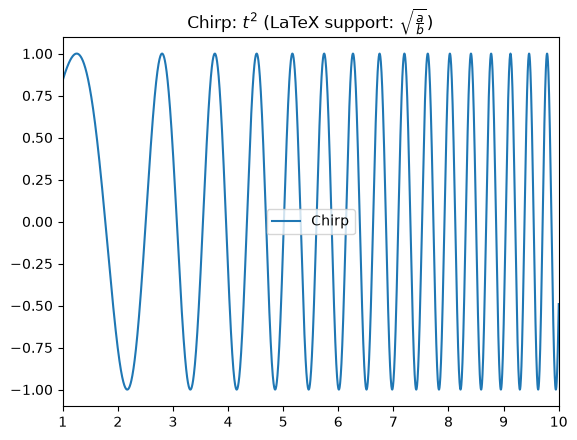

In [78]:
t = np.linspace(1, 130, 44000)
chirp = np.sin(t**2)
plt.plot(t, chirp, label='Chirp')
plt.xlim(1, 10)
plt.title('Chirp: $t^2$ (LaTeX support: $\\sqrt{\\frac{a}{b}}$)')
plt.legend();
plt.show()

By the way, why do we call this a chirp (or a quadratic chirp)? To get the answer, let's play the data through a speaker:

In [79]:
from IPython.display import Audio, display
display(Audio(data=chirp, rate=44000))

Let's now activate the interactive mode (see also ``%matplotlib``):

In [80]:
%matplotlib notebook
%matplotlib notebook

In [81]:
plt.plot([1,2,3], [2,4,5]);

<IPython.core.display.Javascript object>

We can now interactively click on the figure above and also augment it with code:

In [82]:
plt.title('Title added later!')
plt.xlabel('Time [$t$]');

### Interactive usage

In this course we will often use interactivity when working with graphical displays. For this purpose we first import `interact` from the `ipywidgets` package:

In [83]:
from ipywidgets import interact

Then we define the figure as a function with the arguments `amplitude`, `fr`, `phase`, and `damping`:

In [84]:
def figure_plot(amplitude=1, fr=10, phase=0, damping=0.):
    t = np.linspace(0, 1, 200)
    f = amplitude * np.sin(2*np.pi*fr*t - phase) * np.exp(-damping*2*np.pi*fr*t)
    plt.plot(t, f)
    plt.ylim(-5, 5)
    plt.show()

Let's go back to inline usage and call the function for plotting the figure (with default arguments):

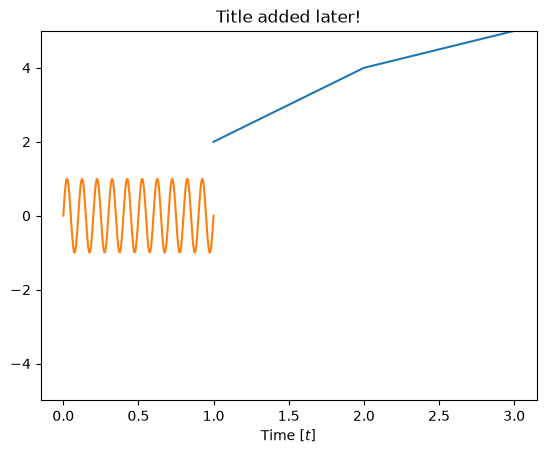

In [85]:
%matplotlib inline
figure_plot()

If we pass the figure-plotting function to the `interact` function, the latter takes care of the interactive controls with which we can change the parameters for calling the `figure_plot` function:

In [86]:
interact(figure_plot);

interactive(children=(IntSlider(value=1, description='amplitude', max=3, min=-1), IntSlider(value=10, descript…

We can also define the parameter ranges ourselves:

In [87]:
interact(figure_plot, amplitude=(1, 5, 1), damping=(0, 1, 0.05), fr=(10, 100, 1), phase=(0, 2*np.pi, np.pi/180));

interactive(children=(IntSlider(value=1, description='amplitude', max=5, min=1), IntSlider(value=10, descripti…

### Advanced usage

#### Displaying multiple functions

Let's look at a simple example of displaying multiple functions (first, optionally, let's define the fonts for output to pdf):

In [88]:
from matplotlib import rc
rc('font',**{'family':'serif'})
plt.rcParams['pdf.fonttype'] = 42

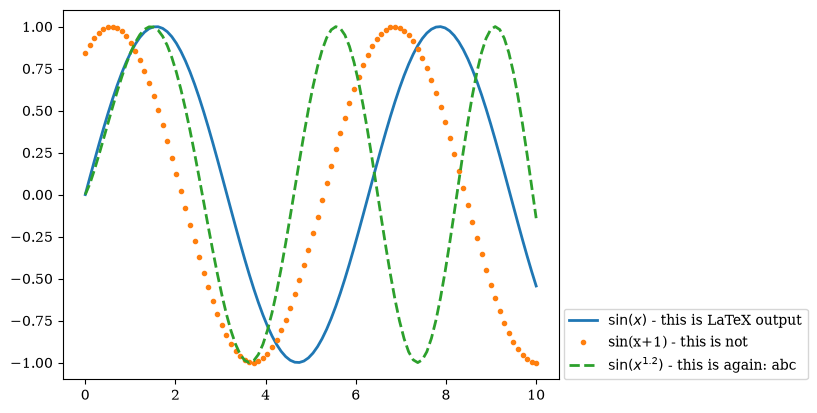

In [89]:
x = np.linspace(0, 10, 100)

y1 = np.sin(x)
y2 = np.sin(x+1)
y3 = np.sin(x**1.2)

plt.plot(x, y1, '-', label=r'$\sin(x)$ - this is LaTeX output', linewidth = 2);
plt.plot(x, y2, '.', label='sin(x+1) - this is not', linewidth = 2);
plt.plot(x, y3, '--', label=r'$\sin(x^{1.2})$ - this is again: abc', linewidth = 2);
plt.legend(loc=(1.01,0));
plt.savefig('data/prvi plot.pdf')

#### Displaying multiple figures

We display multiple figures using the method `subplot`, which defines a grid and the position of the next plot.
```python
plt.subplot(2, 2, 1)
plt.plot(x, y1, 'r')
plt.subplot(2, 2, 2)
plt.plot(x, y2, 'g')
```
In the example above `plt.subplot(2, 2, 1)` means: let the grid be `2 x 2`, draw into figure 1 (top left). Next `plt.subplot(2, 2, 2)` is called, which means a `2 x 2` grid, draw into figure 2 (top right), and so on. Notice that the figure index starts at 1; one could say this is an inconsistency in Python, but the reason is that `matplotlib` was born out of the idea of giving Python users a plotting style as similar as possible to the one they knew in Matlab (where the index starts at 1).

A working example is:

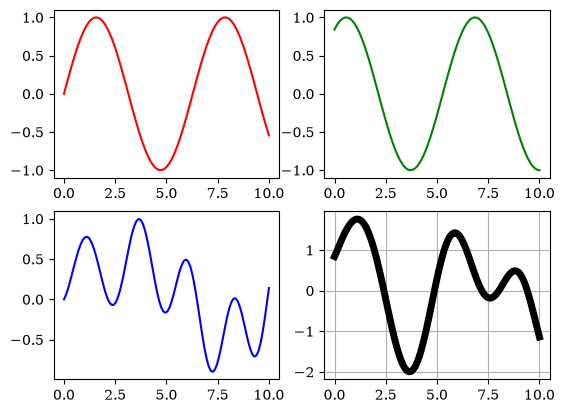

In [90]:
plt.subplot(2, 2, 1)
plt.plot(x, y1, 'r')
plt.subplot(2, 2, 2)
plt.plot(x, y2, 'g')
plt.subplot(2, 2, 3)
plt.plot(x, y2*y3, 'b')
plt.subplot(2, 2, 4)
plt.plot(x, y2+y3, 'k', linewidth=5);
plt.grid()

#### Histogram

Let's generate 10000 normally distributed samples and display them as a histogram:

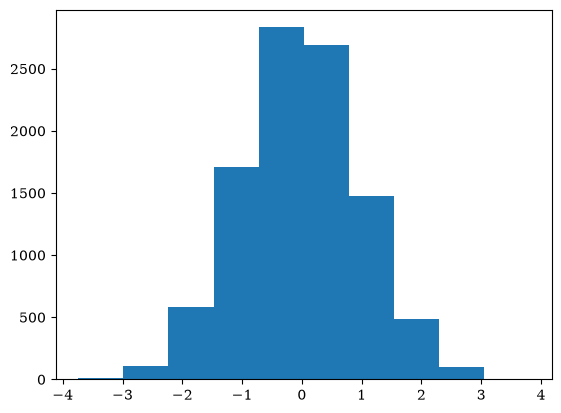

In [91]:
np.random.seed(0)
x = np.random.normal(size=10000)
plt.hist(x);

### Using examples from ``matplotlib.org``

We can import examples from the [gallery](https://matplotlib.org/stable/gallery/index.html) using the magic function `%load`.

Try:

* `%load http://matplotlib.org/mpl_examples/lines_bars_and_markers/fill_demo.py`
* `%load http://matplotlib.org/examples/widgets/slider_demo.py`

# Additional:
## `Numba`

The `numba` package has been developing rapidly in recent times and can speed up numerical execution even further (also in connection with graphics cards, i.e. GPUs).

As an example, here we use `jit` ([just-in-time compilation](http://numba.pydata.org/numba-doc/dev/reference/jit-compilation.html)) from the `numba` package:

In [92]:
import numpy as np
from numba import jit

We use `jit` as a [decorator](https://docs.python.org/3/glossary.html#term-decorator) of the function we want to speed up:

In [93]:
@jit
def dot_product(a, b):
    c = 0
    for i in range(N):
        c += a[i] * b[i]
    return c

Now let's define the vectors:

In [94]:
N = 1000
a = np.arange(N)
b = np.arange(N)

Let's check the speed of the `numpy` dot product:

In [95]:
%%timeit -n1000
a @ b

1.41 μs ± 46.9 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Let's also check the speed of the `numba`-accelerated version. We perform the first call so that the compilation runs, then we measure the time:

In [96]:
dot_product(a, b)

332833500

In [97]:
%%timeit -n1000
dot_product(a, b)

621 ns ± 29.5 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


We see that we improved the speed even further!

## `matplotlib`: animations, callback, XKCD style

With `matplotlib` we can also create **animations**. You can find two examples here:

* [Simple animation](./modules/matplotlib_animation.py),
* [Double pendulum](./modules/double_pendulum_animation.py).

More in the [documentation](https://matplotlib.org/api/animation_api.html#animation).

A figure with a **callback**:

* [Drawing a line](./modules/matplotlib_click.py).

You can also prepare *hand*-drawn figures (**XKCD style**):

* [XKCD style](./modules/xkcd_style.py).

## For the most enthusiastic

1. Learn something new at [chrisalbon.com](http://chrisalbon.com/).

---

# Exercise questions

---

## The ``numpy`` module

**Question 1:** Import the ``numpy`` module under the shorter name ``np``.

Convert an arbitrary list of numbers into a ``numpy`` numerical array, and demonstrate the effect of the ``dtype`` argument.

**Question 2:** using the functions ``numpy.arange`` and ``numpy.linspace``, prepare a numerical array of integers greater than or equal to 0 and less than 10.

**Question 3:** Using a function of the ``numpy`` module, prepare a matrix (two-dimensional numerical array) of zeros, of dimensions $5 \times 6$, and store it in the variable ``A``.

Using the appropriate ``numpy`` command, print the number of rows and the number of columns of the matrix ``A``.

**Question 4:** Fill the first column of the prepared matrix ``A`` with values from an arbitrary numerical array of the appropriate length.

**Question 5:** From the prepared matrix ``A``, using array slicing, prepare a square matrix ``B`` by omitting the first column.

**Question 6:** In the matrix ``A``, replace the first row with ones. Print the matrix ``B`` and comment.

### Operations on numerical arrays

**Question 7:** Prepare a numerical array with the values of the maximum elements of each row of the prepared matrix A.

**Question 8:** On the prepared numerical array, observe the use of basic mathematical operations on numerical arrays (``*, /, //, sin, cos, sqrt``...).

Comment on the difference compared to lists!

### Linear algebra with ``numpy``

**Question 9:** Prepare an identity matrix ``I``. Multiply it by an arbitrary vector of the appropriate length.

**Question 10:** Compute the inverse of the matrix ``M`` and verify the correctness of the result using matrix multiplication.

In [107]:
# Given data
M = np.array([[1, 5, 5], [2,1,3], [7.2, 7, 1.2]])

**Question 11:** Using ``numpy`` tools, solve the system of linear equations ``Mx = b``.

In [109]:
# Given data
M = np.array([[1, 5, 5], [2,1,3], [7.2, 7, 1.2]])
b = np.array([1,2,3])

-------

## The ``matplotlib`` module

In [111]:
from matplotlib import pyplot as plt

**Question 12:** Using ``matplotlib.pyplot``, plot the curves defined below on the same graph. Demonstrate the use of different line types and colors.

In [112]:
# Given data
t = np.linspace(1,10,300)
x = 2*np.sin(t+2) -1
y = 2*np.sin(t)
z = 1.5*np.cos(t**2)

**Question 13:** On the graph plotted above, demonstrate the use of a legend, a title, and axis labels, and draw the coordinate grid.